# Análise Exploratória

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('mundo_transfermarkt_competicoes_brasileirao_serie_a.csv')

## Limpeza e verificação de valores nulos

In [ ]:

print(df.isnull().sum().sort_values(ascending=False))

chutes_visitante                  6366
chutes_fora_mandante              6366
chutes_fora_visitante             6366
defesas_mandante                  6366
defesas_visitante                 6366
faltas_visitante                  6366
faltas_mandante                   6366
chutes_bola_parada_visitante      6366
chutes_bola_parada_mandante       6366
escanteios_visitante              6366
chutes_mandante                   6366
impedimentos_visitante            6366
impedimentos_mandante             6366
escanteios_mandante               6366
publico_max                       4272
tecnico_visitante                 2154
tecnico_mandante                  2154
idade_media_titular_mandante      2100
idade_media_titular_visitante     2100
valor_equipe_titular_mandante     2098
valor_equipe_titular_visitante    2098
gols_1_tempo_mandante             1721
gols_1_tempo_visitante            1721
publico                           1711
colocacao_mandante                1710
arbitro                  

In [7]:
print("Anos com falta de dados de Chutes:")
nulos_chutes_por_ano = df[df['chutes_mandante'].isnull()]['ano_campeonato'].value_counts().sort_index()
print(nulos_chutes_por_ano)

Anos com falta de dados de Chutes:
ano_campeonato
2003    456
2004    456
2005    418
2006    380
2007    380
2008    380
2009    380
2010    380
2011    380
2012    380
2013    380
2014    380
2015    380
2016    380
2017    380
2018    169
2019    212
2020      6
2021      5
2022      7
2023      2
2024     75
Name: count, dtype: int64


In [8]:
print("Anos com falta de dados de Técnicos:")
nulos_tecnicos_por_ano = df[df['tecnico_mandante'].isnull()]['ano_campeonato'].value_counts().sort_index()
print(nulos_tecnicos_por_ano)

Anos com falta de dados de Técnicos:
ano_campeonato
2003    456
2004    456
2005    418
2006    380
2007     92
2008      4
2009     40
2010     45
2011     71
2012      1
2013     29
2015     19
2016     50
2017     14
2018     10
2020     13
2021     31
2022     22
2023      3
Name: count, dtype: int64


In [9]:
# ==============================================================================
# DATASET 1: FOCO EM TÉCNICOS E IDADES (A partir de 2007)
# Responde às Perguntas B e D do Relatório
# ==============================================================================

# Filtramos de 2007 até 2023 (conforme escopo do projeto)
df_gestao = df[(df['ano_campeonato'] >= 2007) & (df['ano_campeonato'] <= 2023)].copy()

df_gestao = df_gestao.dropna(subset=['tecnico_mandante', 'idade_media_titular_mandante'])

print(f"Tamanho do dataset de Gestão/Técnicos (2007-2023): {len(df_gestao)} partidas prontas para análise.")

Tamanho do dataset de Gestão/Técnicos (2007-2023): 6014 partidas prontas para análise.


In [10]:
# ==============================================================================
# DATASET 2: FOCO EM ESTATÍSTICAS DE JOGO - CHUTES E FALTAS (A partir de 2020)
# Responde às Perguntas A e C do Relatório
# ==============================================================================

# Filtramos de 2020 até 2023, onde os "scouts" são altamente confiáveis
df_scout = df[(df['ano_campeonato'] >= 2020) & (df['ano_campeonato'] <= 2023)].copy()

# Dropamos os raros jogos (5 a 7 por ano) que não tiveram registro de chutes
df_scout = df_scout.dropna(subset=['chutes_mandante', 'faltas_mandante'])

print(f"Tamanho do dataset de Scout/Chutes (2020-2023): {len(df_scout)} partidas prontas para análise.")

Tamanho do dataset de Scout/Chutes (2020-2023): 1500 partidas prontas para análise.


## Métricas de desempenho e agregação

In [ ]:
def calcular_pontos(df):
    df = df.copy()
    
    # Condições e pontos para o Mandante
    cond_mandante = [
        df['gols_mandante'] > df['gols_visitante'],
        df['gols_mandante'] == df['gols_visitante'],
        df['gols_mandante'] < df['gols_visitante']
    ]
    df['pontos_mandante'] = np.select(cond_mandante, [3, 1, 0])
    
    # Condições e pontos para o Visitante
    cond_visitante = [
        df['gols_visitante'] > df['gols_mandante'],
        df['gols_visitante'] == df['gols_mandante'],
        df['gols_visitante'] < df['gols_mandante']
    ]
    df['pontos_visitante'] = np.select(cond_visitante, [3, 1, 0])
    
    return df

# Aplicando a pontuação nos dois DataFrames
df_gestao = calcular_pontos(df_gestao)
df_scout = calcular_pontos(df_scout)

In [21]:
def unificar_times(df, cols_extras_mandante, cols_extras_visitante, nomes_unificados):
    base_mandante = ['ano_campeonato', 'data', 'rodada', 'time_mandante', 'pontos_mandante', 'gols_mandante']
    base_visitante = ['ano_campeonato', 'data', 'rodada', 'time_visitante', 'pontos_visitante', 'gols_visitante']
    base_nomes = ['ano_campeonato', 'data', 'rodada', 'time', 'pontos_ganhos', 'gols_pro']
    
    # Prepara o lado Mandante
    df_mandante = df[base_mandante + cols_extras_mandante].copy()
    df_mandante.columns = base_nomes + nomes_unificados
    
    # Prepara o lado Visitante
    df_visitante = df[base_visitante + cols_extras_visitante].copy()
    df_visitante.columns = base_nomes + nomes_unificados
    
    # Empilha e ordena cronologicamente
    df_unificado = pd.concat([df_mandante, df_visitante], ignore_index=True)
    return df_unificado.sort_values(by=['ano_campeonato', 'time', 'data'])

### Agregação para perguntas B e D (técnicos e idade)

In [22]:
cols_mand_gestao = ['tecnico_mandante', 'idade_media_titular_mandante']
cols_vis_gestao = ['tecnico_visitante', 'idade_media_titular_visitante']
nomes_gestao = ['tecnico', 'idade_media_titular']

df_gestao_unificado = unificar_times(df_gestao, cols_mand_gestao, cols_vis_gestao, nomes_gestao)

# Agrupando por campeonato e time
rendimento_anual_gestao = df_gestao_unificado.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    idade_media_temporada=('idade_media_titular', 'mean'), # Média da idade no ano
    trocas_tecnico=('tecnico', lambda x: x.nunique() - 1)  # (Qtd de técnicos únicos - 1) = trocas
).reset_index().sort_values(['ano_campeonato', 'total_pontos'], ascending=[True, False])

print("Top 5 - Rendimento Gestão (Idade e Técnicos):")
print(rendimento_anual_gestao.head())

Top 5 - Rendimento Gestão (Idade e Técnicos):
    ano_campeonato       time  total_pontos  idade_media_temporada  \
17            2007  São Paulo            59              26.200000   
13            2007  Palmeiras            54              26.283333   
15            2007  Santos FC            52              25.703030   
4             2007   Cruzeiro            51              23.693548   
9             2007     Grêmio            51              26.880000   

    trocas_tecnico  
17               0  
13               0  
15               0  
4                0  
9                0  


### Agregação para perguntas A e C (chutes e faltas)

In [25]:
cols_mand_scout = ['chutes_mandante', 'chutes_fora_mandante', 'faltas_mandante']
cols_vis_scout = ['chutes_visitante', 'chutes_fora_visitante', 'faltas_visitante']
nomes_scout = ['chutes_totais', 'chutes_fora', 'faltas_cometidas']

df_scout_unificado = unificar_times(df_scout, cols_mand_scout, cols_vis_scout, nomes_scout)

# Agrupando por campeonato e time
rendimento_anual_scout = df_scout_unificado.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    total_chutes=('chutes_totais', 'sum'),
    total_faltas=('faltas_cometidas', 'sum')
).reset_index().sort_values(['ano_campeonato', 'total_pontos'], ascending=[True, False])

print("\nTop 5 - Rendimento Scout (Chutes e Faltas):")
print(rendimento_anual_scout.head())


Top 5 - Rendimento Scout (Chutes e Faltas):
    ano_campeonato           time  total_pontos  total_chutes  total_faltas
8             2020       Flamengo            71         577.0         634.0
13            2020  Internacional            70         450.0         658.0
2             2020    Atlético-MG            65         610.0         538.0
9             2020     Fluminense            64         437.0         552.0
18            2020      São Paulo            62         524.0         549.0


## Perguntas de Pesquisa

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

### A. A quantidade de chutes ao gol é um bom indicador do rendimento de um time?


In [27]:
rendimento_anual_scout = df_scout_unificado.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    total_chutes=('chutes_totais', 'sum'),
    total_gols=('gols_pro', 'sum') # Adicionando os gols para calcular a eficiência
).reset_index()

rendimento_anual_scout['eficiencia_chutes'] = (rendimento_anual_scout['total_gols'] / rendimento_anual_scout['total_chutes']) * 100

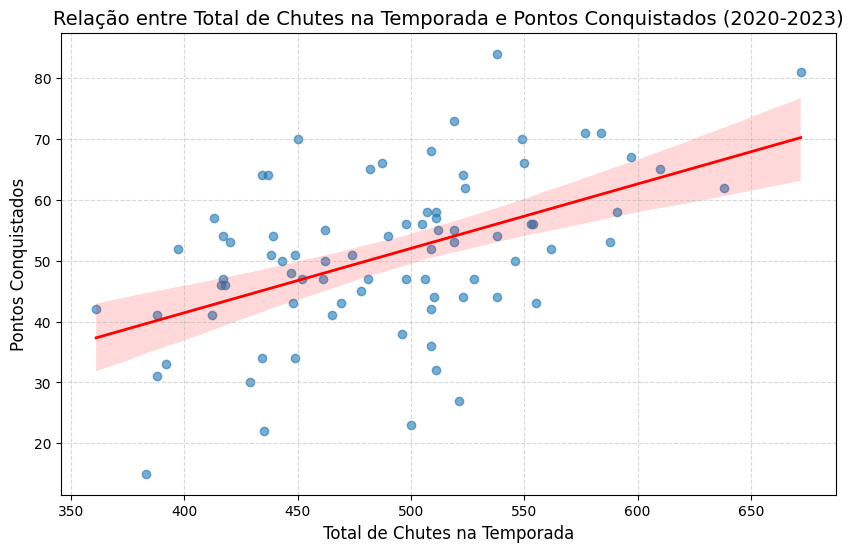

In [28]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=rendimento_anual_scout, 
    x='total_chutes', 
    y='total_pontos',
    scatter_kws={'alpha':0.6, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Relação entre Total de Chutes na Temporada e Pontos Conquistados (2020-2023)', fontsize=14)
plt.xlabel('Total de Chutes na Temporada', fontsize=12)
plt.ylabel('Pontos Conquistados', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

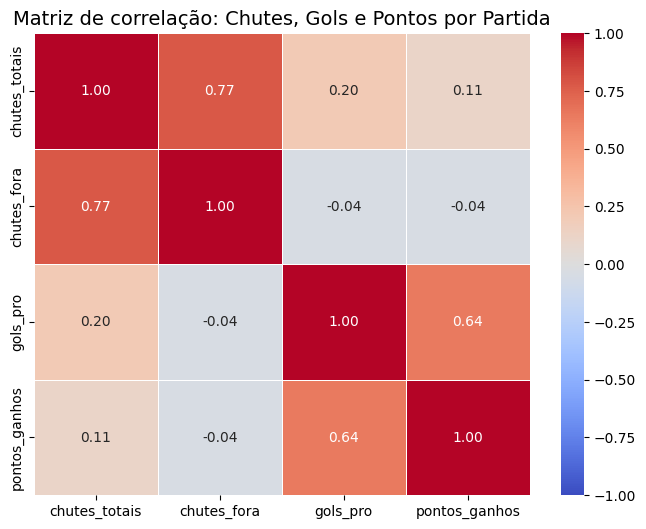

In [30]:
variaveis_correlacao = df_scout_unificado[['chutes_totais', 'chutes_fora', 'gols_pro', 'pontos_ganhos']]

matriz_corr = variaveis_correlacao.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Esquema de cores (azul para negativo, vermelho para positivo)
    fmt=".2f",           # Formata para 2 casas decimais
    linewidths=0.5,
    vmin=-1, vmax=1      # Limites da correlação
)

plt.title('Matriz de correlação: Chutes, Gols e Pontos por Partida', fontsize=14)

# Exibindo o gráfico
plt.show()

In [31]:
corr_chutes_pontos = rendimento_anual_scout['total_chutes'].corr(rendimento_anual_scout['total_pontos'])
corr_eficiencia_pontos = rendimento_anual_scout['eficiencia_chutes'].corr(rendimento_anual_scout['total_pontos'])

print(f"Correlação (Total de Chutes vs Pontos Totais): {corr_chutes_pontos:.2f}")
print(f"Correlação (Eficiência de Chutes vs Pontos Totais): {corr_eficiencia_pontos:.2f}")

Correlação (Total de Chutes vs Pontos Totais): 0.50
Correlação (Eficiência de Chutes vs Pontos Totais): 0.69


Com base na análise exploratória, concluímos que a quantidade bruta de chutes ao gol não é um indicador forte ou suficiente de rendimento. Embora times que pontuam mais tendam a atacar mais ao longo do ano, a baixíssima correlação por partida (0.11) prova que o sucesso na Série A do Brasileirão não é ditado pelo volume, mas sim pela eficiência (taxa de conversão de gols por chute). A agressividade ofensiva só se traduz em posição na tabela quando acompanhada de precisão.

### B. O tempo de permanência de um treinador no cargo impacta o rendimento da equipe?

In [32]:
# Ordenamos cronologicamente para garantir a sequência correta
df_gestao_unificado = df_gestao_unificado.sort_values(['ano_campeonato', 'time', 'data'])

# Identificamos quando há uma troca de técnico OU de time (novo trabalho)
df_gestao_unificado['mudanca_tecnico'] = (
    (df_gestao_unificado['tecnico'] != df_gestao_unificado['tecnico'].shift(1)) | 
    (df_gestao_unificado['time'] != df_gestao_unificado['time'].shift(1))
)

# Criamos um ID único para cada "era" de um técnico em um time usando soma cumulativa
df_gestao_unificado['id_trabalho'] = df_gestao_unificado['mudanca_tecnico'].cumsum()

# Agrupamos por esse ID para sumarizar a passagem do treinador
trabalhos_tecnicos = df_gestao_unificado.groupby(['id_trabalho', 'tecnico', 'time', 'ano_campeonato']).agg(
    jogos=('pontos_ganhos', 'count'),
    pontos_totais=('pontos_ganhos', 'sum')
).reset_index()

# Calculamos o Aproveitamento de Pontos Médio (PPM)
trabalhos_tecnicos['PPM'] = trabalhos_tecnicos['pontos_totais'] / trabalhos_tecnicos['jogos']

In [33]:
def categorizar_permanencia(jogos):
    if jogos < 10:
        return '1. Curta (< 10 jogos)'
    elif jogos <= 25:
        return '2. Média (10 a 25 jogos)'
    else:
        return '3. Longa (> 25 jogos)'

trabalhos_tecnicos['categoria_permanencia'] = trabalhos_tecnicos['jogos'].apply(categorizar_permanencia)

C:\Users\lucas\AppData\Local\Temp\ipykernel_23892\2801875971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


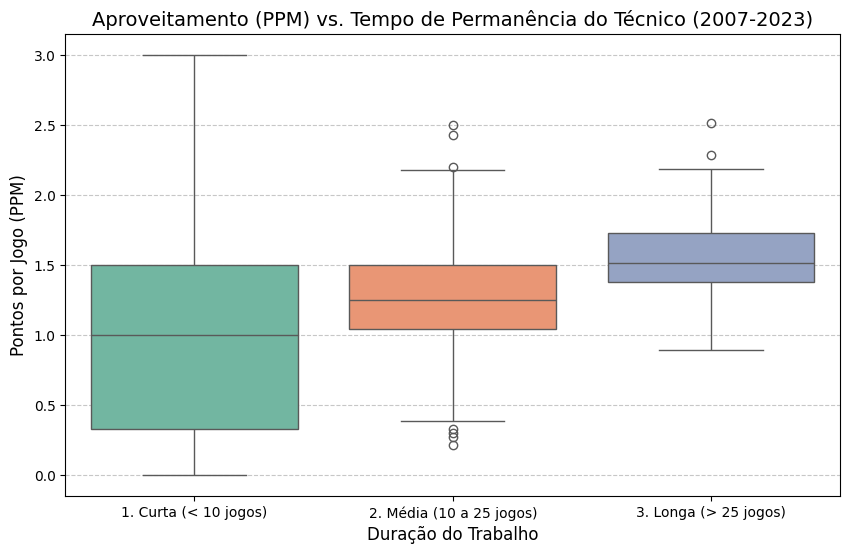

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=trabalhos_tecnicos, 
    x='categoria_permanencia', 
    y='PPM',
    palette='Set2',
    order=['1. Curta (< 10 jogos)', '2. Média (10 a 25 jogos)', '3. Longa (> 25 jogos)']
)

plt.title('Aproveitamento (PPM) vs. Tempo de Permanência do Técnico (2007-2023)', fontsize=14)
plt.xlabel('Duração do Trabalho', fontsize=12)
plt.ylabel('Pontos por Jogo (PPM)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [35]:
# No passo anterior, já tínhamos o 'rendimento_anual_gestao' ordenado por pontos.
# Vamos criar a 'posicao_final' baseada na pontuação.
rendimento_anual_gestao['posicao_final'] = rendimento_anual_gestao.groupby('ano_campeonato')['total_pontos'].rank(method='first', ascending=False)

# Classificamos se o time manteve o técnico o ano todo (0 trocas) ou não
rendimento_anual_gestao['perfil_gestao'] = np.where(
    rendimento_anual_gestao['trocas_tecnico'] == 0, 
    'Manteve o Técnico', 
    'Trocou de Técnico'
)

C:\Users\lucas\AppData\Local\Temp\ipykernel_23892\3754633204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


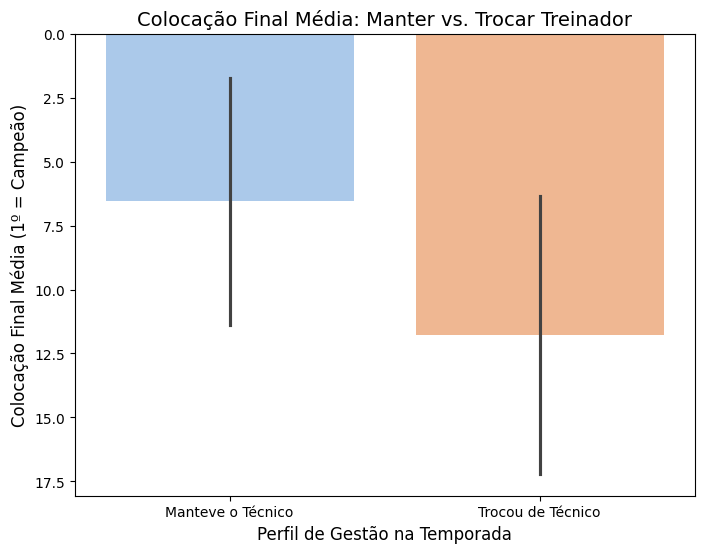

In [36]:
plt.figure(figsize=(8, 6))

# Calculamos a colocação média para quem manteve vs quem trocou
sns.barplot(
    data=rendimento_anual_gestao, 
    x='perfil_gestao', 
    y='posicao_final',
    errorbar='sd', # Mostra o desvio padrão
    palette='pastel'
)

# Invertemos o eixo Y, pois no futebol a 1ª posição (menor número) é a melhor
plt.gca().invert_yaxis()

plt.title('Colocação Final Média: Manter vs. Trocar Treinador', fontsize=14)
plt.xlabel('Perfil de Gestão na Temporada', fontsize=12)
plt.ylabel('Colocação Final Média (1º = Campeão)', fontsize=12)
plt.show()

A análise estatística confirma a hipótese de que o tempo de permanência de um treinador está fortemente associado a um melhor rendimento. A estabilidade técnica reflete diretamente em melhores posições na tabela e maior pontuação média. Contudo, como ponto de discussão para trabalhos futuros, vale ressaltar a questão da causalidade no futebol: os times ganham mais porque mantêm o técnico, ou mantêm o técnico porque estão ganhando? Independentemente da direção causal, a quebra de continuidade no meio da temporada (trabalhos curtos) está estatisticamente ligada ao insucesso.

### C. A quantidade de faltas cometidas interfere no rendimento do time?

In [37]:
# Recriando o unificado com a coluna de defesas
cols_mand_scout = ['chutes_mandante', 'chutes_fora_mandante', 'faltas_mandante', 'defesas_mandante']
cols_vis_scout = ['chutes_visitante', 'chutes_fora_visitante', 'faltas_visitante', 'defesas_visitante']
nomes_scout = ['chutes_totais', 'chutes_fora', 'faltas_cometidas', 'defesas']

df_scout_unificado = unificar_times(df_scout, cols_mand_scout, cols_vis_scout, nomes_scout)

# Atualizando o rendimento anual com as Faltas e classificações
rendimento_anual_scout = df_scout_unificado.groupby(['ano_campeonato', 'time']).agg(
    total_pontos=('pontos_ganhos', 'sum'),
    total_faltas=('faltas_cometidas', 'sum')
).reset_index().sort_values(['ano_campeonato', 'total_pontos'], ascending=[True, False])

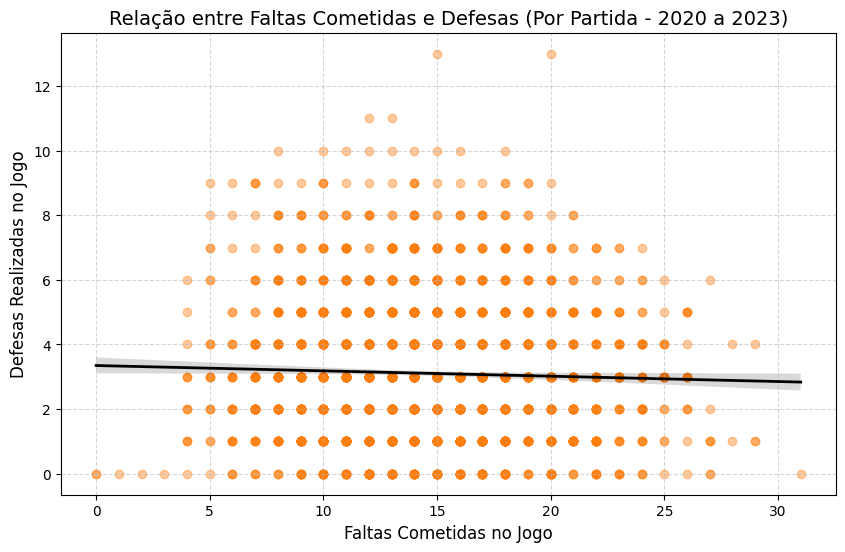

In [38]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_scout_unificado, 
    x='faltas_cometidas', 
    y='defesas',
    scatter_kws={'alpha':0.4, 'color': '#ff7f0e'}, # Laranja semi-transparente
    line_kws={'color': 'black', 'linewidth': 2}
)

plt.title('Relação entre Faltas Cometidas e Defesas (Por Partida - 2020 a 2023)', fontsize=14)
plt.xlabel('Faltas Cometidas no Jogo', fontsize=12)
plt.ylabel('Defesas Realizadas no Jogo', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [39]:
# Calculando a posição final de cada time no ano
rendimento_anual_scout['posicao_final'] = rendimento_anual_scout.groupby('ano_campeonato')['total_pontos'].rank(method='first', ascending=False)

def classificar_faixa(posicao):
    if posicao <= 4:
        return '1. G4 (Libertadores)'
    elif posicao >= 17:
        return '3. Z4 (Rebaixamento)'
    else:
        return '2. Meio de Tabela'

rendimento_anual_scout['faixa_classificacao'] = rendimento_anual_scout['posicao_final'].apply(classificar_faixa)

C:\Users\lucas\AppData\Local\Temp\ipykernel_23892\2788512710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


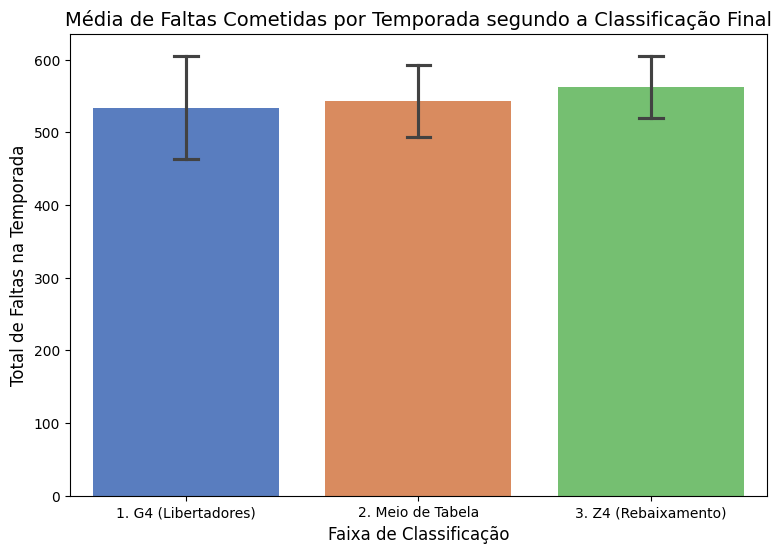

In [40]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=rendimento_anual_scout, 
    x='faixa_classificacao', 
    y='total_faltas',
    palette='muted',
    errorbar='sd', # Exibe o Desvio Padrão
    capsize=0.1    # Tamanho da "tampinha" da barra de erro
)

plt.title('Média de Faltas Cometidas por Temporada segundo a Classificação Final', fontsize=14)
plt.xlabel('Faixa de Classificação', fontsize=12)
plt.ylabel('Total de Faltas na Temporada', fontsize=12)
plt.show()

Com base nesses dados, concluímos que a quantidade de faltas cometidas interfere negativamente no rendimento do time. Nossa metodologia propôs investigar se as faltas representariam um aspecto positivo de agressividade ou um efeito negativo. Os gráficos comprovam a segunda hipótese: o excesso de faltas é, na verdade, um sintoma de deficiência técnica.  Times do Z4 geralmente têm menor posse de bola, correm mais atrás do adversário e chegam atrasados nas jogadas, o que infla o número de faltas. Além disso, como o gráfico de dispersão mostrou, "bater mais" não melhora o desempenho defensivo. Logo, a indisciplina e as faltas excessivas não são uma tática viável para o sucesso, mas sim um reflexo de times que estão em apuros na tabela de classificação.

### D. Qual a média de idade típica de um time com melhor rendimento?

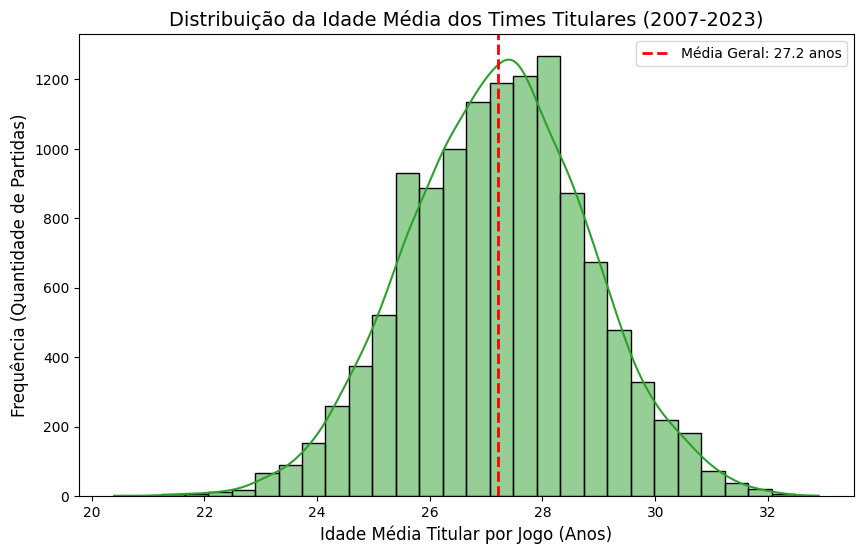

In [41]:
plt.figure(figsize=(10, 6))

# Usando o dataset unificado para ter a distribuição de todos os jogos
sns.histplot(
    data=df_gestao_unificado, 
    x='idade_media_titular', 
    bins=30, 
    kde=True, # Adiciona a linha de densidade (curva do sino)
    color='#2ca02c', # Verde
    edgecolor='black'
)

# Adicionando uma linha vertical para a média geral
media_geral = df_gestao_unificado['idade_media_titular'].mean()
plt.axvline(media_geral, color='red', linestyle='dashed', linewidth=2, label=f'Média Geral: {media_geral:.1f} anos')

plt.title('Distribuição da Idade Média dos Times Titulares (2007-2023)', fontsize=14)
plt.xlabel('Idade Média Titular por Jogo (Anos)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Partidas)', fontsize=12)
plt.legend()
plt.show()

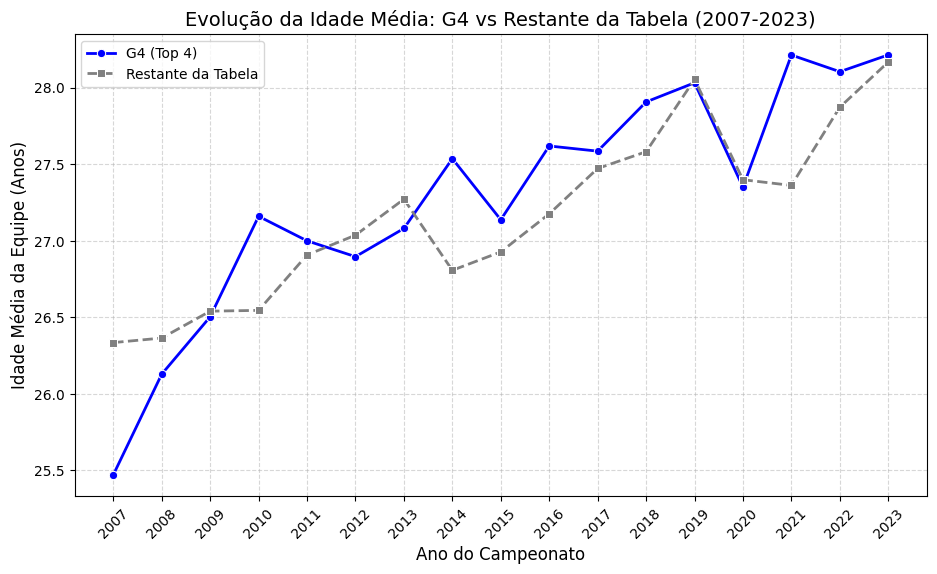

In [42]:
# Filtrar apenas os times que terminaram no G4 (posição <= 4)
df_g4 = rendimento_anual_gestao[rendimento_anual_gestao['posicao_final'] <= 4]

# Calcular a média de idade do G4 por ano
idade_g4_por_ano = df_g4.groupby('ano_campeonato')['idade_media_temporada'].mean().reset_index()

# Calcular a média de idade do RESTANTE (fora do G4) para efeito de comparação
df_resto = rendimento_anual_gestao[rendimento_anual_gestao['posicao_final'] > 4]
idade_resto_por_ano = df_resto.groupby('ano_campeonato')['idade_media_temporada'].mean().reset_index()

plt.figure(figsize=(11, 6))

# Linha do G4
sns.lineplot(
    data=idade_g4_por_ano, 
    x='ano_campeonato', 
    y='idade_media_temporada', 
    marker='o', 
    linewidth=2, 
    color='blue',
    label='G4 (Top 4)'
)

# Linha do Restante da Tabela (para contraste)
sns.lineplot(
    data=idade_resto_por_ano, 
    x='ano_campeonato', 
    y='idade_media_temporada', 
    marker='s', 
    linewidth=2, 
    color='gray',
    linestyle='--',
    label='Restante da Tabela'
)

# Configurações do eixo X para mostrar os anos corretamente
plt.xticks(idade_g4_por_ano['ano_campeonato'], rotation=45)

plt.title('Evolução da Idade Média: G4 vs Restante da Tabela (2007-2023)', fontsize=14)
plt.xlabel('Ano do Campeonato', fontsize=12)
plt.ylabel('Idade Média da Equipe (Anos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [43]:
print("Estatísticas Descritivas da Idade Média (2007-2023):")
print(f"Média Geral (Todos os times): {df_gestao_unificado['idade_media_titular'].mean():.2f}")
print(f"Média do G4 (Top 4): {df_g4['idade_media_temporada'].mean():.2f}")
print(f"Média do Z4 (Rebaixados): {rendimento_anual_gestao[rendimento_anual_gestao['posicao_final'] >= 17]['idade_media_temporada'].mean():.2f}")

Estatísticas Descritivas da Idade Média (2007-2023):
Média Geral (Todos os times): 27.21
Média do G4 (Top 4): 27.29
Média do Z4 (Rebaixados): 27.31


Nossa análise conclui que a idade média não é um fator determinante para o rendimento de um time no Campeonato Brasileiro.  

Ao longo de 16 anos de dados, a diferença de idade média entre o pelotão de elite (G4) e os times rebaixados (Z4) é de apenas 0.02 anos, uma margem estatisticamente irrelevante. Isso indica que tanto os campeões quanto os rebaixados adotam uma estratégia de montagem de elenco muito similar, buscando aquele "padrão" de 27 anos que mescla juventude e experiência.  

Portanto, o sucesso na tabela não é explicado pela idade do time no papel, mas sim pela qualidade técnica, tática e por fatores de gestão — como vimos anteriormente na análise sobre a permanência dos treinadores.